# Hard Rock: seleção congelada e prévia técnica

**Os 20 candidatos aguardam conferência musical. Os valores aqui não são resultados da amostra principal e não são usados para decidir correspondência.**

Regras: [protocolo operacional](../docs/workshop-protocolo.md). Este caderno não faz downloads. Executar antes `scripts/download_pilot_sources.py`; o lock está versionado. Requer as bibliotecas de `requirements-workshop.txt`.

Audiência é a contagem histórica do vídeo no dia declarado 2023-02-07, sem timestamp individual. Datas de catálogo não são primeiros lançamentos validados. O rótulo de gênero é operacional.

In [1]:
from pathlib import Path
import json, sys, subprocess, statistics, hashlib
from collections import Counter
ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists(): ROOT = ROOT.parent
assert (ROOT / "data/workshop/selection-lock.json").exists()
sys.path.insert(0, str(ROOT / "scripts"))
from prepare_workshop import inventory, SEED
from analyze_workshop import read_review
lock, review, lock_hash = read_review(ROOT)
print("Protocolo:", lock["protocol"])
print("SHA-256 do lock:", lock_hash)
print("Revisão:", dict(Counter(r["decision"] for r in review)))


Protocolo: docs/workshop-protocolo.md
SHA-256 do lock: d69e21e986e05dbe8fff536cb7b8d64a71ba3a877c5a7c9efb78a5a4e649e304
Revisão: {'pending': 20}


In [2]:
# Verificar hashes e recalcular seleção apenas por metadados.
audit, linked = inventory(ROOT)
observations = json.loads((ROOT / "data/processed/hard-rock-catalogue-observations.json").read_text())
catalogue = {r["track_id"]: r for r in observations}
eligible = [r for r in linked if not r["metadata_exclusion_reasons"]
            and catalogue[r["track_id"]].get("identity_verified")
            and catalogue[r["track_id"]].get("catalogue_year")]
decade = [r for r in eligible if 1980 <= catalogue[r["track_id"]]["catalogue_year"] <= 1989]
first_by_artist = {}
for r in sorted(decade, key=lambda r: hashlib.sha256(f"{SEED}|{r['track_id']}".encode()).hexdigest()):
    first_by_artist.setdefault(r["Artist"], r)
assert {r["track_id"] for r in first_by_artist.values()} == {r["track_id"] for r in lock["candidates"]}
assert statistics.median(r["views"] for r in first_by_artist.values()) == lock["audience_cutoff_views"]
max_five = max(len({r["Artist"] for r in eligible if start <= catalogue[r["track_id"]]["catalogue_year"] <= start+4}) for start in range(1965, 2023))
print("IDs no rótulo:", audit["genre_unique_ids"], "; interseção:", audit["intersection_rows"])
print("Elegíveis por metadados:", len(eligible), "; artistas:", len({r["Artist"] for r in eligible}))
print("Máximo de artistas em cinco anos:", max_five)
print("Década:", len(decade), "faixas; artistas:", len(first_by_artist))
print("Grupos congelados:", lock["groups"], "; corte:", lock["audience_cutoff_views"])


IDs no rótulo: 998 ; interseção: 176
Elegíveis por metadados: 129 ; artistas: 39
Máximo de artistas em cinco anos: 15
Década: 47 faixas; artistas: 20
Grupos congelados: {'lower': 10, 'higher': 10} ; corte: 89776313.5


## Definições verificadas

Fonte primária: [Spotify](https://developer.spotify.com/documentation/web-api/reference/get-audio-features); evidências em `data/workshop/reference-evidence.json`.

- Energy: intensidade e atividade perceptuais, de 0 a 1.
- Danceability: adequação estimada para dança a partir de andamento, estabilidade rítmica, força da batida e regularidade, de 0 a 1.
- Acousticness: confiança de que a faixa é acústica, de 0 a 1.

São valores fornecidos no snapshot para a faixa Spotify, não medidas calculadas neste estudo sobre o vídeo inteiro nem avaliações subjetivas do ouvinte.

In [3]:
run = subprocess.run([sys.executable, str(ROOT / "scripts/analyze_workshop.py"), "--root", str(ROOT), "--preview"], cwd=ROOT, capture_output=True, text=True)
if run.returncode != 0: raise RuntimeError(run.stderr or run.stdout)
summary = json.loads((ROOT / "data/processed/hard-rock-candidates-preview-summary.json").read_text())
assert summary["not_a_main_result"] is True
assert summary["selection_lock_sha256"] == lock_hash
print(summary["stage"], summary["flow"])
print("Software:", summary["software"])


candidates-preview {'candidates': 20, 'decisions': {'pending': 20}, 'review_exclusions': [], 'feature_exclusions': [], 'plotted': 20, 'group_counts': {'lower': 10, 'higher': 10}}
Software: {'python': '3.12.14', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}


In [4]:
# Valores de candidatos não validados; sujeitos às perdas da curadoria.
for feature, groups in summary["summaries"].items():
    for group, m in groups.items():
        print(feature, group, "n=", m["n"], "mediana=", round(m["median"],4), "IIQ=", [round(m[k],4) for k in ["q1","q3"]])
print("Contexto e ausências:", json.dumps(summary["context"], ensure_ascii=False))


Energy lower n= 10 mediana= 0.9275 IIQ= [0.8412, 0.9537]
Energy higher n= 10 mediana= 0.7545 IIQ= [0.7007, 0.83]
Danceability lower n= 10 mediana= 0.5295 IIQ= [0.3327, 0.5745]
Danceability higher n= 10 mediana= 0.3505 IIQ= [0.271, 0.4953]
Acousticness lower n= 10 mediana= 0.0173 IIQ= [0.0043, 0.0496]
Acousticness higher n= 10 mediana= 0.026 IIQ= [0.0127, 0.1107]
Contexto e ausências: {"lower": {"n": 10, "distinct_artists": 10, "catalogue_year_min": 1980, "catalogue_year_median": 1985.0, "catalogue_year_max": 1988, "video_publication_available": 0, "video_age_years_median": null, "formats": {"pending": 10}}, "higher": {"n": 10, "distinct_artists": 10, "catalogue_year_min": 1980, "catalogue_year_median": 1984.0, "catalogue_year_max": 1989, "video_publication_available": 0, "video_age_years_median": null, "formats": {"pending": 10}}}


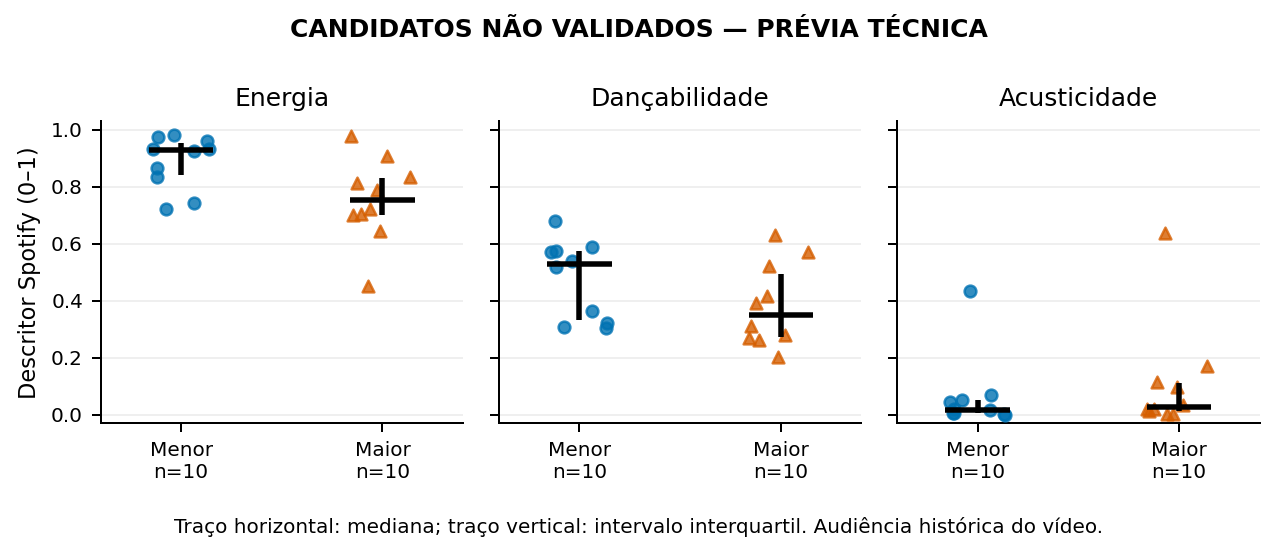

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(plt.imread(ROOT / "figures/hard-rock-candidates-preview.png"))
ax.axis("off")
plt.tight_layout()
plt.show()


## Barreira para a análise principal

Exigir decisões atribuídas em todos os casos e pelo menos cinco gravações válidas por grupo. Os IDs e o corte não mudam após exclusões. Não há reserva. O assistente não ouviu os áudios: registrar relatos do autor por ID, sem converter candidatos em gravações aprovadas.

In [6]:
run_main = subprocess.run([sys.executable, str(ROOT / "scripts/analyze_workshop.py"), "--root", str(ROOT)], cwd=ROOT, capture_output=True, text=True)
print(run_main.stdout.strip())
if any(r["decision"] == "pending" for r in review):
    assert run_main.returncode == 2
    print("Análise principal corretamente bloqueada enquanto a curadoria está pendente.")
else: assert run_main.returncode in (0, 2)


PENDENTE: complete a revisão dos 20 candidatos antes da análise principal.
Análise principal corretamente bloqueada enquanto a curadoria está pendente.
